# 02. LangGraph 기본

## 학습 목표
- LangGraph의 핵심 개념(State, Node, Edge)을 이해한다
- `TypedDict`와 `add_messages`를 사용하여 State를 정의할 수 있다
- `StateGraph`로 기본 챗봇 그래프를 구성할 수 있다
- 그래프를 시각화하고 조건부 엣지를 활용할 수 있다

## 1. 환경 설정

In [1]:
import sys
print(sys.executable)

c:\Users\kimsa\Desktop\VS_ryo\cs_prac\.venv\Scripts\python.exe


In [2]:
from dotenv import load_dotenv
load_dotenv()

import os
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY가 .env 파일에 설정되어 있는지 확인하세요!"
print("환경 설정 완료!")

환경 설정 완료!


## 2. State 정의 (TypedDict + add_messages)

LangGraph에서 **State**는 그래프가 관리하는 데이터입니다.

- `TypedDict`: 상태의 구조를 정의
- `add_messages`: 메시지 리스트를 자동으로 누적해주는 리듀서(reducer)

In [3]:
from typing import Annotated, cast
from typing_extensions import TypedDict
from langgraph.graph import add_messages
from langgraph.graph.message import Messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# State 정의
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]  # 메시지 누적 리듀서

# add_messages 동작 확인
# 기존 메시지 리스트에 새 메시지를 추가하면 누적됩니다
existing = [HumanMessage(content="안녕하세요")]
new = [AIMessage(content="안녕하세요! 무엇을 도와드릴까요?")]

# list[HumanMessage] 등은 list 불변성 때문에 Messages로 단언해야 타입 검사기가 통과합니다
result = add_messages(cast(Messages, existing), cast(Messages, new))
for msg in cast(list[BaseMessage], result):
    print(f"  [{msg.type}] {msg.content}")

c:\Users\kimsa\Desktop\VS_ryo\cs_prac\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


  [human] 안녕하세요
  [ai] 안녕하세요! 무엇을 도와드릴까요?


## 3. Node 함수 만들기 (LLM 호출 노드)

Node는 그래프에서 실제 작업을 수행하는 함수입니다.

- 입력: 현재 State
- 출력: State 업데이트 (dict)

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-mini")

# 챗봇 노드 함수
def chatbot(state: ChatState) -> dict:
    """현재 메시지를 기반으로 LLM 응답을 생성합니다."""
    response = llm.invoke(state["messages"])
    # add_messages 리듀서가 자동으로 기존 메시지에 추가합니다
    return {"messages": [response]}

print("chatbot 노드 함수 정의 완료!")
print(f"입력: ChatState (messages 리스트)")
print(f"출력: dict (새 메시지를 담은 messages 키)")

chatbot 노드 함수 정의 완료!
입력: ChatState (messages 리스트)
출력: dict (새 메시지를 담은 messages 키)


## 4. 기본 그래프 구성 (START -> chatbot -> END)

가장 간단한 그래프: 시작 -> 챗봇 노드 -> 종료

In [5]:
from langgraph.graph import StateGraph, START, END

# 1) 그래프 빌더 생성
graph_builder = StateGraph(ChatState)

# 2) 노드 추가
graph_builder.add_node("chatbot", chatbot)

# 3) 엣지 추가
graph_builder.add_edge(START, "chatbot")  # 시작 -> 챗봇
graph_builder.add_edge("chatbot", END)     # 챗봇 -> 종료

# 4) 그래프 컴파일
graph = graph_builder.compile()

# 5) 실행
result = graph.invoke({
    "messages": [HumanMessage(content="LangGraph가 뭔지 한 문장으로 설명해줘")]
})

# 결과 출력
for msg in result["messages"]:
    print(f"[{msg.type}] {msg.content}")

[human] LangGraph가 뭔지 한 문장으로 설명해줘
[ai] LangGraph는 언어 모델(LLM)과 도구·데이터 처리 컴포넌트를 노드로 연결해 복잡한 작업 흐름을 그래프 형태로 설계·실행·시각화하는 오케스트레이션 프레임워크입니다.


## 5. 그래프 시각화

그래프 구조를 ASCII와 Mermaid 다이어그램으로 시각화합니다.

=== ASCII 그래프 ===
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | chatbot |   
 +---------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   



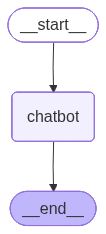

In [11]:
# ASCII 시각화 (print_ascii는 grandalf 패키지 필요: pip install grandalf)
# pip install 후에도 에러나면: grandalf 없이 graph_ascii가 먼저 로드된 커널 캐시 때문 → 아래 reload 또는 커널 재시작
import importlib
import langchain_core.runnables.graph_ascii as _lc_gascii
importlib.reload(_lc_gascii)
print("=== ASCII 그래프 ===")
graph.get_graph().print_ascii()
print()

# Mermaid 다이어그램 (노트북에서 이미지로 표시)
try:
    from IPython.display import Image, display
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception as e:
    print(f"Mermaid PNG 생성 실패 (pyppeteer 필요): {e}")
    print("대신 Mermaid 텍스트를 출력합니다:")
    print(graph.get_graph().draw_mermaid())

## 6. 조건부 엣지: 감정 분석 챗봇

사용자의 메시지 감정(긍정/부정)에 따라 다른 노드로 분기하는 그래프를 만들어봅시다.

```
START -> analyze_sentiment --긍정--> positive_response -> END
                           --부정--> negative_response -> END
```

In [12]:
from langchain_core.messages import SystemMessage

# State 정의 (감정 필드 추가)
class SentimentState(TypedDict):
    messages: Annotated[list, add_messages]
    sentiment: str  # "positive" 또는 "negative"

# 노드 1: 감정 분석
def analyze_sentiment(state: SentimentState) -> dict:
    """사용자 메시지의 감정을 분석합니다."""
    last_raw = state["messages"][-1].content
    last_message = last_raw if isinstance(last_raw, str) else str(last_raw)

    analysis_prompt = [
        SystemMessage(content="다음 텍스트의 감정을 분석하세요. 'positive' 또는 'negative' 중 하나만 답하세요."),
        HumanMessage(content=last_message)
    ]
    result = llm.invoke(analysis_prompt)
    out = result.content
    out_str = out if isinstance(out, str) else str(out)
    sentiment = "positive" if "positive" in out_str.lower() else "negative"
    print(f"  [감정 분석] {sentiment}")
    return {"sentiment": sentiment}

# 노드 2: 긍정 응답
def positive_response(state: SentimentState) -> dict:
    """긍정적인 메시지에 대한 응답"""
    prompt_messages = [
        SystemMessage(content="사용자가 긍정적인 감정을 표현했습니다. 함께 기뻐하며 밝은 에너지로 응답하세요."),
        *state["messages"]
    ]
    response = llm.invoke(prompt_messages)
    return {"messages": [response]}

# 노드 3: 부정 응답
def negative_response(state: SentimentState) -> dict:
    """부정적인 메시지에 대한 응답"""
    prompt_messages = [
        SystemMessage(content="사용자가 부정적인 감정을 표현했습니다. 공감하고 위로하며 따뜻하게 응답하세요."),
        *state["messages"]
    ]
    response = llm.invoke(prompt_messages)
    return {"messages": [response]}

# 라우팅 함수
def route_by_sentiment(state: SentimentState) -> str:
    """감정에 따라 다음 노드를 결정합니다."""
    return "positive_response" if state["sentiment"] == "positive" else "negative_response"

# 그래프 구성
sentiment_builder = StateGraph(SentimentState)

# 노드 추가
sentiment_builder.add_node("analyze_sentiment", analyze_sentiment)
sentiment_builder.add_node("positive_response", positive_response)
sentiment_builder.add_node("negative_response", negative_response)

# 엣지 추가
sentiment_builder.add_edge(START, "analyze_sentiment")
sentiment_builder.add_conditional_edges(
    "analyze_sentiment",
    route_by_sentiment,
    {"positive_response": "positive_response", "negative_response": "negative_response"}
)
sentiment_builder.add_edge("positive_response", END)
sentiment_builder.add_edge("negative_response", END)

# 컴파일
sentiment_graph = sentiment_builder.compile()

# 시각화
sentiment_graph.get_graph().print_ascii()

                    +-----------+                      
                    | __start__ |                      
                    +-----------+                      
                          *                            
                          *                            
                          *                            
                +-------------------+                  
                | analyze_sentiment |                  
                +-------------------+                  
                  ..              ..                   
               ...                  ...                
             ..                        ..              
+-------------------+           +-------------------+  
| negative_response |           | positive_response |  
+-------------------+           +-------------------+  
                  **              **                   
                    ***        ***                     
                       **    **                 

In [13]:
# 테스트: 긍정적인 메시지
print("=== 긍정 테스트 ===")
result = sentiment_graph.invoke({
    "messages": [HumanMessage(content="오늘 시험에 합격했어요! 너무 기뻐요!")],
    "sentiment": ""
})
print(f"응답: {result['messages'][-1].content}")
print()

# 테스트: 부정적인 메시지
print("=== 부정 테스트 ===")
result = sentiment_graph.invoke({
    "messages": [HumanMessage(content="프로젝트 발표를 망쳤어요. 너무 속상합니다.")],
    "sentiment": ""
})
print(f"응답: {result['messages'][-1].content}")

=== 긍정 테스트 ===
  [감정 분석] positive
응답: 와—정말 축하드려요! 🎉🎉 합격 소식 들으니 저도 기분 좋아요! 대단해요, 그동안 정말 열심히 준비하셨겠죠? 😊

원하시면 함께 축하 문구(카카오톡·인스타·페이스북용) 만들어 드릴게요. 아니면 지금 기분 전하는 방법(맛있는 거 먹기, 소소한 파티, 푹 쉬기)도 추천해 드릴게요. 또 다음 단계(증서 발급, 이력서·포트폴리오 업데이트, 다음 시험 준비 등) 계획 세우는 것도 도와드릴게요—어떤 도움을 원하세요?

=== 부정 테스트 ===
  [감정 분석] negative
응답: 정말 속상하셨겠어요. 열심히 준비하셨을 텐데 기대한 대로 안 되면 누구라도 크게 낙담하죠. 지금 느끼는 감정은 자연스러운 거예요 — 화나고, 창피하고, 억울할 수도 있어요. 그런 감정을 인정하고 조금 쉬어주세요.

조금 진정되면 해볼 수 있는 실질적 단계들을 제안할게요.
- 잠깐 휴식: 심호흡 몇 번, 짧은 산책이나 따뜻한 차 한 잔으로 마음을 가라앉히세요. (간단한 호흡법: 4초 들이쉬고 4초 멈추고 6초 천천히 내쉬기)
- 상황 점검: 무엇이 잘못됐는지(기술적 문제, 자료 준비, 멘탈 등)와 그래도 잘된 부분을 한 번 적어보세요. 객관적으로 정리하면 대처가 쉬워져요.
- 피드백 얻기: 발표를 함께 본 동료나 상사에게 구체적인 피드백을 요청하세요. 개선할 점이 명확해지면 다음엔 더 잘할 수 있어요.
- 빠른 보완: 핵심 메시지가 잘 전달되지 않았다면 짧은 이메일이나 보충자료로 정리해서 공유하는 것도 좋아요. 필요하면 제가 문장 만들어 드릴게요.
- 다음 기회 준비: 다음 발표를 위해 연습 루틴이나 슬라이드 구조, 예상 질문 목록을 만들어두면 불안이 많이 줄어듭니다.

원하시면 지금 바로 보낼 수 있는 짧은 보완/사과 메일 예시를 만들어 드릴게요. 또는 오늘 있었던 일을 말해주시면 함께 정리하고 다음 계획을 세워드릴게요. 괜찮으세요? 제가 곁에 있을게요.


## 7. 실습 과제: 문서 분류 워크플로우 만들기

사용자가 입력한 텍스트를 분류하고, 카테고리에 따라 다른 처리를 하는 그래프를 만드세요.

### 요구사항
1. `classify` 노드: LLM으로 텍스트를 3개 카테고리 중 하나로 분류 (예: 기술, 비즈니스, 일상)
2. 각 카테고리별 처리 노드: 분류 결과에 따라 다른 스타일로 요약/응답
3. 조건부 엣지로 연결
4. 그래프 시각화
5. 최소 3개 테스트 메시지로 검증

In [15]:
# 실습: 문서 분류 워크플로우 (기술 / 비즈니스 / 일상)
# 이전 셀에서 llm(ChatOpenAI), HumanMessage 등이 정의되어 있어야 합니다.

from typing import Annotated

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, add_messages
from typing_extensions import TypedDict

# 1) State 정의
class DocWorkflowState(TypedDict):
    messages: Annotated[list, add_messages]
    category: str  # "기술" | "비즈니스" | "일상"


def _last_user_text(state: DocWorkflowState) -> str:
    raw = state["messages"][-1].content
    return raw if isinstance(raw, str) else str(raw)


def _normalize_category(text: str) -> str:
    """모델 출력을 세 카테고리 중 하나로 정규화."""
    t = text.strip().lower()
    if "기술" in text or "tech" in t or "technical" in t:
        return "기술"
    if "비즈니스" in text or "business" in t or "biz" in t:
        return "비즈니스"
    if "일상" in text or "daily" in t or "life" in t:
        return "일상"
    return "일상"


# 2) 노드 함수 정의
def classify(state: DocWorkflowState) -> dict:
    """LLM으로 텍스트를 세 카테고리 중 하나로 분류."""
    user_text = _last_user_text(state)
    prompt = [
        SystemMessage(
            content=(
                "사용자 메시지를 아래 세 가지 중 정확히 하나로만 분류하세요.\n"
                "답변 본문은 반드시 한 단어만: 기술 / 비즈니스 / 일상\n"
                "다른 설명 없이 한 단어만 출력하세요."
            )
        ),
        HumanMessage(content=user_text),
    ]
    result = llm.invoke(prompt)
    out = result.content
    out_str = out if isinstance(out, str) else str(out)
    cat = _normalize_category(out_str)
    print(f"  [분류] {cat} (모델 원문: {out_str.strip()[:60]!r})")
    return {"category": cat}


def handle_tech(state: DocWorkflowState) -> dict:
    """기술: 전문·간결 요약/응답."""
    prompt_messages = [
        SystemMessage(
            content="기술 관련 텍스트입니다. 핵심 용어를 유지하며 짧게 요약하고, 필요하면 불릿으로 정리하세요."
        ),
        *state["messages"],
    ]
    response = llm.invoke(prompt_messages)
    return {"messages": [response]}


def handle_business(state: DocWorkflowState) -> dict:
    """비즈니스: 인사이트·실행 포인트 중심."""
    prompt_messages = [
        SystemMessage(
            content="비즈니스 맥락입니다. 배경·이슈·제안을 구분해 요약하고, 다음 액션 아이디어를 1~2개 제시하세요."
        ),
        *state["messages"],
    ]
    response = llm.invoke(prompt_messages)
    return {"messages": [response]}


def handle_daily(state: DocWorkflowState) -> dict:
    """일상: 친근한 톤."""
    prompt_messages = [
        SystemMessage(content="일상 대화입니다. 따뜻하고 가볍게 몇 문장으로 응답하세요."),
        *state["messages"],
    ]
    response = llm.invoke(prompt_messages)
    return {"messages": [response]}


# 3) 라우팅 함수 정의
def route_by_category(state: DocWorkflowState) -> str:
    c = state["category"]
    if c == "기술":
        return "handle_tech"
    if c == "비즈니스":
        return "handle_business"
    return "handle_daily"


# 4) 그래프 구성 및 컴파일
doc_builder = StateGraph(DocWorkflowState)
doc_builder.add_node("classify", classify)
doc_builder.add_node("handle_tech", handle_tech)
doc_builder.add_node("handle_business", handle_business)
doc_builder.add_node("handle_daily", handle_daily)

doc_builder.add_edge(START, "classify")
doc_builder.add_conditional_edges(
    "classify",
    route_by_category,
    {
        "handle_tech": "handle_tech",
        "handle_business": "handle_business",
        "handle_daily": "handle_daily",
    },
)
doc_builder.add_edge("handle_tech", END)
doc_builder.add_edge("handle_business", END)
doc_builder.add_edge("handle_daily", END)

doc_workflow_graph = doc_builder.compile()

# 5) 시각화
import importlib

import langchain_core.runnables.graph_ascii as _lc_gascii

importlib.reload(_lc_gascii)
print("=== 문서 분류 워크플로우 (ASCII) ===")
doc_workflow_graph.get_graph().print_ascii()

# 6) 테스트 (3개)
tests = [
    ("기술", "Python에서 asyncio 이벤트 루프가 뭐고, 왜 쓰는지 초등학생도 이해할 수 있게 설명해줘."),
    ("비즈니스", "우리 스타트업이 B2B SaaS로 전환할 때 검토해야 할 가격·채널 포인트를 정리해줘."),
    ("일상", "오늘 친구랑 카페에서 수다 떨다가 시간 가는 줄 몰랐어. 기분 좋은 하루였어."),
]

for i, (hint, text) in enumerate(tests, 1):
    print(f"\n=== 테스트 {i} (예시 힌트: {hint}) ===")
    out = doc_workflow_graph.invoke(
        {"messages": [HumanMessage(content=text)], "category": ""}
    )
    final = out["messages"][-1].content
    final_text = final if isinstance(final, str) else str(final)
    print(f"저장된 카테고리: {out['category']}")
    preview = final_text if len(final_text) <= 900 else final_text[:900] + "..."
    print(f"응답:\n{preview}")


=== 문서 분류 워크플로우 (ASCII) ===
                              +-----------+                              
                              | __start__ |                              
                              +-----------+                              
                                     *                                   
                                     *                                   
                                     *                                   
                               +----------+                              
                              .| classify |..                            
                          .... +----------+  ....                        
                     .....           .           .....                   
                 ....                 .               ....               
              ...                     .                   ...            
+-----------------+           +--------------+           +-------------+ 
| handle_b